<img src="image.png" width="20%" alt="alt text">


# Steam Games Dataset

# Índice
1. Introducción
- 1.1. Objetivos
- 1.2. Alcance y Estructura

2. Descripción del dataset

3. Limpieza de datos

4. Análisis Exploratorio de Datos (EDA)

5. Análisis Agregado de Desarrolladores y Editores

6. Conclusiones

7. Bibliografía

# 1. Introducción
La industria del videojuego ha experimentado un crecimiento notable en los últimos años, consolidándose como uno de los principales sectores del entretenimiento digital. Plataformas como Steam concentran una gran cantidad de información sobre juegos, usuarios y patrones de consumo, lo que las convierte en una fuente de datos especialmente interesante para el análisis.

### Objetivos
En este trabajo se realiza un análisis exploratorio de un conjunto de datos de juegos disponibles en Steam, con el objetivo de estudiar sus características principales y su relación con métricas de popularidad y valoración por parte de los usuarios. El análisis se apoya en técnicas de limpieza, transformación y exploración de datos utilizando Python y librerías habituales en ciencia de datos.

### Alcance y estructura
El estudio se centra en variables estructuradas como géneros, categorías, idiomas soportados, precio, número estimado de propietarios y métricas de valoración, descartando información puramente descriptiva o multimedia que no aporta valor al análisis cuantitativo. El resultado es un dataset depurado que permite extraer patrones generales sobre el comportamiento y la recepción de los juegos en la plataforma.

# 2. Descripción del dataset
El conjunto de datos utilizado contiene información sobre juegos disponibles en la plataforma Steam y ha sido obtenido a partir de un dataset público de Kaggle: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset. Cada registro representa un juego identificado de forma única mediante la variable appid, que se empleará como índice del dataset.

El dataset incluye variables relacionadas con las características de los juegos, su precio, métricas de popularidad y valoración por parte de los usuarios. Previamente al análisis, los datos deberán ser sometidos a un proceso de limpieza y preprocesamiento para obtener un conjunto de datos coherente y adecuado para el análisis exploratorio.

# 3. Limpieza de datos

## Importación de librerías

In [268]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import ast 
from sklearn.preprocessing import MultiLabelBinarizer
import re
from collections import Counter
from wordcloud import WordCloud

In [198]:
# Se establece la ruta del dataset
ruta = os.path.join("res", "games_march2025_cleaned.csv")
df = pd.read_csv(ruta, sep=",")

In [199]:
# Realizamos una primera vista a los datos
df.head(5)

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


In [200]:
# Realizamos una vista de las columnas del dataset
df.keys()

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url',
       'achievements', 'recommendations', 'notes', 'supported_languages',
       'full_audio_languages', 'packages', 'developers', 'publishers',
       'categories', 'genres', 'screenshots', 'movies', 'user_score',
       'score_rank', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'tags', 'pct_pos_total', 'num_reviews_total',
       'pct_pos_recent', 'num_reviews_recent'],
      dtype='object')

## Eliminación y limpieza de columnas

En esta primera fase de limpieza se procede a eliminar las variables que no aportan valor analítico directo, presentan información redundante, o cuyo contenido es principalmente descriptivo o multimedia, y por tanto no son adecuadas para un análisis cuantitativo o exploratorio.

Las variables eliminadas son las siguientes:
- detailed_description, about_the_game, short_description: Variables de texto destinadas a la descripción del contenido del juego.

- header_image, screenshots, movies: Variables de tipo multimedia (URLs de imágenes y vídeos) que no aportan información numérica ni categórica útil para el análisis.

- website, support_url, support_email, metacritic_url: Información de contacto o enlaces externos sin valor analítico en términos de comportamiento, popularidad o características del juego.

- packages: Variable compleja y altamente heterogénea relacionada con opciones de compra. No resulta comparable entre juegos y complica innecesariamente el análisis.

- score_rank y user_score: Variables con una muy elevada proporción de valores nulos o sin variabilidad significativa, además de ser redundantes frente a otras métricas de valoración más completas.

- notes: Texto libre con advertencias o anotaciones generales, sin estructura ni valor cuantitativo.

- full_audio_languages: Variable similar conceptualmente a supported_languages, pero con menor cobertura y relevancia. La información principal sobre idiomas ya queda recogida en la variable de idiomas soportados.

- tags: Variable de muy alta cardinalidad y estructura heterogénea, cuya inclusión incrementaría notablemente la complejidad del dataset sin aportar un valor proporcional en esta primera fase del análisis.

Además, usaremos la columna de 'AppID' como índice semántico

In [201]:
cols_eliminar=["detailed_description", "about_the_game", "short_description", "header_image", "website", "support_url", "support_email",
    "metacritic_url", "screenshots", "movies", "packages", "score_rank", "user_score", "notes", "full_audio_languages", "tags"]

# Eliminamos las columnas previamente elegidas
df.drop(cols_eliminar, axis=1, inplace=True)

# Establecemos appid como índice semántico
df.set_index("appid", inplace=True)

Para evitar posibles columnas completas de 0 o NaN, hacemos una limpieza genérica.

In [202]:
# Establecemos las columnas con todo 0 o todo NaN en una lista comprimida
cols_eliminar=[c for c in df.columns if (df[c]==0).all() or (df[c]==np.nan).all()]

# Las eliminamos del dataset
df.drop(columns=cols_eliminar, inplace=True)

cols_eliminar  # Para ver qué se eliminó

[]

No hay ninguna columna vacía.

In [203]:
# Vemos con info la información básica del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89618 entries, 730 to 763730
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   name                      89618 non-null  object 
 1   release_date              89618 non-null  object 
 2   required_age              89618 non-null  int64  
 3   price                     89618 non-null  float64
 4   dlc_count                 89618 non-null  int64  
 5   reviews                   10401 non-null  object 
 6   windows                   89618 non-null  bool   
 7   mac                       89618 non-null  bool   
 8   linux                     89618 non-null  bool   
 9   metacritic_score          89618 non-null  int64  
 10  achievements              89618 non-null  int64  
 11  recommendations           89618 non-null  int64  
 12  supported_languages       89618 non-null  object 
 13  developers                89618 non-null  object 
 14  publishe

## Variables categóricas

Para poder llevar a cabo el análisis del dataset de juegos de Steam, es necesario transformar algunas de las variables categóricas en una representación numérica que permita su tratamiento estadístico, ya que el tipo de datos de muchas es un str o un dict, cuando necesitamos lists.

In [204]:
cols_categoricas=df.select_dtypes(include=["object", "category"]).columns
print(cols_categoricas)

Index(['name', 'release_date', 'reviews', 'supported_languages', 'developers',
       'publishers', 'categories', 'genres', 'estimated_owners'],
      dtype='object')


Para poder realizar el análisis, las variables multietiquetas deben ser parseadas a listas de Python y posteriormente codificada mediante multi-hot encoding, generando una variable binaria por cada variable dentro de las variables categóricas presentes en el dataset. Las variables multietiqueta a parsear son:

In [205]:
cols_categoricas_parsear=["supported_languages", "genres", "categories", "release_date", "estimated_owners", "developers", "publishers"]

### Lenguajes soportados

In [206]:
display(df["supported_languages"])

appid
730        ['Czech', 'Danish', 'Dutch', 'English', 'Finni...
578080     ['English', 'Korean', 'Simplified Chinese', 'F...
570        ['Bulgarian', 'Czech', 'Danish', 'Dutch', 'Eng...
271590     ['English', 'French', 'Italian', 'German', 'Sp...
359550     ['English', 'French', 'Italian', 'German', 'Sp...
                                 ...                        
2115110                                          ['English']
1174200                               ['English', 'Turkish']
1160190                                          ['English']
3380340    ['English', 'Simplified Chinese', 'French', 'G...
763730                                           ['English']
Name: supported_languages, Length: 89618, dtype: object

In [207]:
# Realizamos el parse de string a list 
df["languages_list_sucia"]=df["supported_languages"].apply(lambda x : ast.literal_eval(x) if pd.notnull(x) else [])

# Codificación multi-hot. Detecta todas las etiquetas únicas y crea una columna binaria para cada una
mlb_sucia=MultiLabelBinarizer()  

# Se crea una matriz donde cada fila es un juego y las columnas son variables binarias de los idiomas
languages_encoded_sucia=mlb_sucia.fit_transform(df["languages_list_sucia"]) 

# Crea un dataframe aparte con todo el multihot encoding
df_languages=pd.DataFrame(languages_encoded_sucia, columns=mlb_sucia.classes_, index=df.index) 

# Guardamos el nombre de las columnas
lang_cols_sucia=df_languages.columns.tolist()

In [208]:
print(lang_cols_sucia)

['\r\nFrench', '\r\nGerman', 'Afrikaans', 'Albanian', 'Amharic', 'Arabic', 'Armenian', 'Assamese', 'Azerbaijani', 'Bangla', 'Basque', 'Belarusian', 'Bosnian', 'Bulgarian', 'Catalan', 'Cherokee', 'Croatian', 'Czech', 'Danish', 'Dari', 'Dutch', 'English', 'English[b][/b]', 'Estonian', 'Filipino', 'Finnish', 'French', 'Galician', 'Georgian', 'German', 'Greek', 'Gujarati', 'Hausa', 'Hebrew', 'Hindi', 'Hungarian', 'Hungarian,Polish', 'Icelandic', 'Igbo', 'Indonesian', 'Irish', 'Italian', 'Japanese', "K'iche'", 'Kannada', 'Kazakh', 'Khmer', 'Kinyarwanda', 'Konkani', 'Korean', 'Kyrgyz', 'Latvian', 'Lithuanian', 'Luxembourgish', 'Macedonian', 'Malay', 'Malayalam', 'Maltese', 'Maori', 'Marathi', 'Mongolian', 'Nepali', 'Norwegian', 'Odia', 'Persian', 'Polish', 'Portuguese - Brazil', 'Portuguese - Portugal', 'Punjabi (Gurmukhi)', 'Punjabi (Shahmukhi)', 'Quechua', 'Romanian', 'Russian', 'Russian\r\n[b][/b]', 'Scots', 'Serbian', 'Simplified Chinese', 'Sindhi', 'Sinhala', 'Slovak', 'Slovenian', 'Sor

Aqui tenemos todos los idiomas disponibles del dataset, sin embargo, podemos observar que esta lista de idiomas no esta "limpia", ya que hay carácteres como saltos de línea, BBCode o idiomas incorrectamente separados o repetidos. El siguiente paso será limpiarlo.

In [209]:
def clean_languages(celda):
    # Si el valor no es una lista, se devuelve una lista vacía para evitar errores.
    if not isinstance(celda, list):
        return []

    languages=[] # Inicializamos la lista de idiomas

    for language in celda:
        # Se eliminan saltos de línea
        language=language.replace("\n", " ").replace("\r", " ").strip()
        
        # Se eliminan etiquetas tipo [b][/b]
        language=re.sub(r"\[.*?\]", "", language).strip()
        
        # Se separan idiomas si vienen unidos por coma
        for part in language.split(","):
            part=part.strip()
            if part:
                languages.append(part)

    # Se eliminan duplicados manteniendo el orden
    unicos=[]
    for l in languages:
        if l not in unicos:
            unicos.append(l)
    return unicos

# Se aplica la función a la lista de idiomas sucia
df["supported_languages_clean"]=df["languages_list_sucia"].apply(clean_languages) 

# Se eliminan columnas intermedias
df.drop(columns=["supported_languages", "languages_list_sucia"], inplace=True) 

Para no tener un dataset demasiado cargado, con idiomas poco relevantes, usaremos los 20 idiomas más frecuentes del dataset.

In [210]:
# Se cuenta la frecuencia de los idiomas
lang_counts=df["supported_languages_clean"].explode().value_counts() 

# Se escogen el top 20 idiomas más usados
top_20_langs=lang_counts.head(20).index.tolist()
top_20_langs

['English',
 'Simplified Chinese',
 'German',
 'French',
 'Japanese',
 'Russian',
 'Spanish - Spain',
 'Italian',
 'Korean',
 'Portuguese - Brazil',
 'Traditional Chinese',
 'Polish',
 'Portuguese - Portugal',
 'Turkish',
 'Spanish - Latin America',
 'Dutch',
 'Ukrainian',
 'Czech',
 'Swedish',
 'Thai']

In [211]:
# Columna de los idiomas del top 20 de cada juego
df["supported_languages_top20"]=df["supported_languages_clean"].apply(lambda langs: [l for l in langs if l in set(top_20_langs)]) 

# Se eliminan columnas intermedias de apoyo
df.drop(columns="supported_languages_clean", inplace=True) 

In [212]:
# Con los idiomas limpios, podemos realizar el multi-hot encoding final
mlb=MultiLabelBinarizer()
lang_encoded=mlb.fit_transform(df["supported_languages_top20"])

# Creamos un dataframe aparte
df_languages=pd.DataFrame(lang_encoded, columns=[mlb.classes_], index=df.index) 

# Se une al DataFrame original
df=pd.concat([df, df_languages], axis=1)
df.drop(columns="supported_languages_top20", inplace=True)

Guardamos una lista de los idiomas presentes en el dataset, que servirá después para realizar análisis.

In [213]:
lang_cols=df_languages.columns.tolist()

### Géneros

In [214]:
display(df["genres"])

appid
730                               ['Action', 'Free To Play']
578080     ['Action', 'Adventure', 'Massively Multiplayer...
570                   ['Action', 'Strategy', 'Free To Play']
271590                               ['Action', 'Adventure']
359550                                            ['Action']
                                 ...                        
2115110                            ['Indie', 'Early Access']
1174200         ['Action', 'Adventure', 'Indie', 'Strategy']
1160190                            ['Indie', 'Early Access']
3380340       ['Adventure', 'RPG', 'Simulation', 'Strategy']
763730                                   ['Action', 'Indie']
Name: genres, Length: 89618, dtype: object

In [215]:
# Parse de string a lista
df["genres_list"]=df["genres"].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Codificación multi-hot
mlb_genre=MultiLabelBinarizer()
genre_encoded=mlb_genre.fit_transform(df["genres_list"])

# Crear DataFrame con nombres de columnas correctos
df_genres=pd.DataFrame(genre_encoded,columns=mlb_genre.classes_,index=df.index)

# Unimos al dataset principal
df=pd.concat([df, df_genres], axis=1)

# Eliminamos columnas auxiliares
df.drop(columns=["genres", "genres_list"], inplace=True)

Guardamos una lista de los géneros presentes en el dataset, que servirá después para realizar análisis.

In [216]:
genre_cols=df_genres.columns.tolist()
genre_cols

['360 Video',
 'Accounting',
 'Action',
 'Adventure',
 'Animation & Modeling',
 'Audio Production',
 'Casual',
 'Design & Illustration',
 'Documentary',
 'Early Access',
 'Education',
 'Episodic',
 'Free To Play',
 'Game Development',
 'Gore',
 'Indie',
 'Massively Multiplayer',
 'Movie',
 'Nudity',
 'Photo Editing',
 'RPG',
 'Racing',
 'Sexual Content',
 'Short',
 'Simulation',
 'Software Training',
 'Sports',
 'Strategy',
 'Tutorial',
 'Utilities',
 'Video Production',
 'Violent',
 'Web Publishing']

### Categorías

In [217]:
# Realizamos el parse de string a list
df["cat_list"]=df["categories"].apply(lambda x: [c[0] if isinstance(c, tuple) else c for c in ast.literal_eval(x)] if pd.notnull(x) else [])

# Codificación multi-hot 
mlb_cat=MultiLabelBinarizer()
cat_encoded=mlb_cat.fit_transform(df["cat_list"])  

# Creamos un dataframe aparte
df_cat=pd.DataFrame(cat_encoded, columns=mlb_cat.classes_, index=df.index) 

# Lo unimos al dataset principal
df=pd.concat([df, df_cat], axis=1) 

# Quitamos las columnas intermedias de apoyo
df.drop(columns=["categories", "cat_list"], inplace=True) 

# Guardamos las categorías en una lista aparte
cat_cols=df_cat.columns.tolist() 

In [218]:
cat_cols

['Captions available',
 'Co-op',
 'Commentary available',
 'Cross-Platform Multiplayer',
 'Family Sharing',
 'Full controller support',
 'HDR available',
 'In-App Purchases',
 'Includes Source SDK',
 'Includes level editor',
 'LAN Co-op',
 'LAN PvP',
 'MMO',
 'Multi-player',
 'Online Co-op',
 'Online PvP',
 'Partial Controller Support',
 'PvP',
 'Remote Play Together',
 'Remote Play on Phone',
 'Remote Play on TV',
 'Remote Play on Tablet',
 'Shared/Split Screen',
 'Shared/Split Screen Co-op',
 'Shared/Split Screen PvP',
 'Single-player',
 'Stats',
 'Steam Achievements',
 'Steam Cloud',
 'Steam Leaderboards',
 'Steam Timeline',
 'Steam Trading Cards',
 'Steam Turn Notifications',
 'Steam Workshop',
 'SteamVR Collectibles',
 'Tracked Controller Support',
 'VR Only',
 'VR Support',
 'VR Supported',
 'Valve Anti-Cheat enabled']

### Fecha de lanzamiento

Normalizamos la variable fecha de lanzamiento

In [219]:
df["release_date"]=pd.to_datetime(df["release_date"], errors="coerce")

In [220]:
display(df["release_date"])

appid
730       2012-08-21
578080    2017-12-21
570       2013-07-09
271590    2015-04-13
359550    2015-12-01
             ...    
2115110   2024-02-29
1174200   2020-01-07
1160190   2019-10-10
3380340   2025-01-25
763730    2018-03-01
Name: release_date, Length: 89618, dtype: datetime64[ns]

### Propietarios del juego

Esta variable contiene un rango aproximado de jugadores, por lo que consideraremos que la mejor opción para poder realizar el análisis es coger el mínimo y el máximo del rango y calcular el valor medio de jugadores aproximado.

In [221]:
df["owners_min"]=df["estimated_owners"].str.split(" - ").str[0].astype(int)
df["owners_max"]=df["estimated_owners"].str.split(" - ").str[1].astype(int)

# Calculamos la media de cada juego
df["owners_mean"]=(df["owners_min"]+df["owners_max"])/2

# Eliminamos columnas intermedias
df.drop(columns=["estimated_owners", "owners_min", "owners_max"], inplace=True)

### Developers y Publishers

In [222]:
df["publishers"].apply(type).value_counts()

publishers
<class 'str'>    89618
Name: count, dtype: int64

Vemos que la fila de developers y publishers son str, por lo que se parsea para que este en list.

In [223]:
# Parseo de str a list
df["developers_list"]=df["developers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
df["publishers_list"]=df["publishers"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

In [224]:
df.drop(columns=["developers", "publishers"], inplace=True)

In [225]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 89618 entries, 730 to 763730
Data columns (total 120 columns):
 #    Column                      Dtype         
---   ------                      -----         
 0    name                        object        
 1    release_date                datetime64[ns]
 2    required_age                int64         
 3    price                       float64       
 4    dlc_count                   int64         
 5    reviews                     object        
 6    windows                     bool          
 7    mac                         bool          
 8    linux                       bool          
 9    metacritic_score            int64         
 10   achievements                int64         
 11   recommendations             int64         
 12   positive                    int64         
 13   negative                    int64         
 14   average_playtime_forever    int64         
 15   average_playtime_2weeks     int64         
 16   medi

Una vez finalizado el proceso de limpieza, podemos decir que hemos obtenido un conjunto de datos coherente y estructurado, adecuado para el análisis exploratorio. Durante esta fase se han eliminado variables sin valor analítico, se homogeneizaron formatos y tipos de datos, y se transformaron aquellas variables categóricas que requerían una representación más adecuada para el análisis cuantitativo.

Con el dataset ya depurado y preparado, disponemos de una base sólida para abordar el análisis exploratorio y la interpretación de resultados en las secciones posteriores.
### Reviews

In [290]:
# Stopwords (sin depender de NLTK)
try:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # Usamos las palabras frecuentes en ingles que no aportan significado
    stopwords=set(ENGLISH_STOP_WORDS)
except Exception:
    stopwords=set()

# Añadimos stopwords mínimas extra comunes en este tipo de textos
stopwords|={"game", "games", "steam", "play", "players", "player", "new", "get", "will", "one", "also", "can", "make", "read", "more", "pc", "gamer"}

# Frases típicas “ruido” en esta columna
noise_patterns=[r"read more.*", r"pc gamer.*", r"^\s*“\s*”\s*"]
    
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    text=text.lower()
    
    # Eliminar patrones de ruido
    for pat in noise_patterns:
        text=re.sub(pat, " ", text)
    
    # Eliminar caracteres no alfabéticos
    text=re.sub(r"[^a-z\s]", " ", text)
    
    # Normalizar espacios
    text=re.sub(r"\s+", " ", text).strip()
    
    # Filtrar palabras de menos de 3 letras y stopwords
    words=[w for w in text.split()if len(w)>=3 and w not in stopwords]
    
    return " ".join(words)

# Limpieza de la columna reviews
reviews_clean=df["reviews"].fillna("").apply(clean_text)

# Palabras más comunes
for text in reviews_clean:
    word_counts.update(text.split())

# Top 20
top_20_words=word_counts.most_common(20)
top_20_words

[('fun', 4452),
 ('like', 4426),
 ('great', 3334),
 ('experience', 2984),
 ('time', 2946),
 ('best', 2856),
 ('just', 2712),
 ('good', 2680),
 ('gaming', 2574),
 ('adventure', 2522),
 ('story', 2430),
 ('really', 2394),
 ('gameplay', 2368),
 ('world', 2036),
 ('indie', 1930),
 ('genre', 1840),
 ('love', 1800),
 ('rock', 1800),
 ('puzzle', 1762),
 ('paper', 1724)]

# Análisis Exploratorio de Datos
En esta sección se realiza un análisis exploratorio de los datos con el objetivo de comprender la distribución de las principales variables y detectar patrones generales en el conjunto ya depurado.
### Visión general del dataset

In [226]:
df.shape

(89618, 120)

Observamos que finalmente tenemos 89618 juegos en el dataset de steam y 119 valores, la mayoría binarias y pertenecientes a las variables a las que se le aplicó el Multi-hot encoding

### Estadísticos descriptivos básicos

Los estadísticos descriptivos aportan una visión numérica global de cada variable, como la media, el mínimo o el máximo.

In [227]:
# Realizamos un estudio de los estadísticos básicos de las variables más importantes
cols_inters=["price", "owners_mean", "positive", "negative", "pct_pos_total", "average_playtime_forever"]

df[cols_inters].describe()

,price,owners_mean,positive,negative,pct_pos_total,average_playtime_forever
count,89618.000000,8.961800e+04,8.961800e+04,8.961800e+04,89618.000000,8.961800e+04
mean,7.309623,1.011338e+05,1.269896e+03,2.098026e+02,45.352418,1.149119e+02
std,13.331073,1.677279e+06,3.181441e+04,6.114314e+03,40.685695,6.814748e+03
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000,0.000000e+00
25%,0.990000,1.000000e+04,1.000000e+00,0.000000e+00,-1.000000,0.000000e+00
50%,4.990000,1.000000e+04,1.000000e+01,2.000000e+00,60.000000,0.000000e+00
75%,9.990000,1.000000e+04,5.800000e+01,1.700000e+01,84.000000,0.000000e+00
max,999.980000,3.500000e+08,7.480813e+06,1.135108e+06,100.000000,1.462997e+06


### Distribución de variables clave
En las distribuciones se muestran la forma real de los datos, algo que los estadísticos por sí solos no siempre revelan.

#### Precio de los juegos

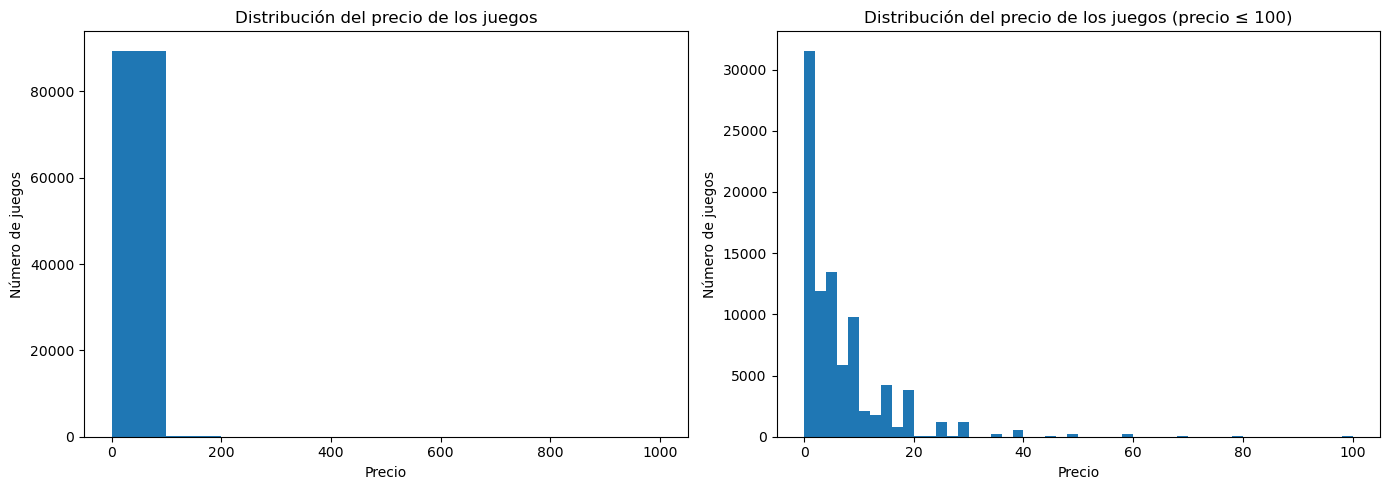

In [228]:
# Crearemos 2 gráficas, la general, que es muy asimétrica, y otra con zoom, con un rango más pequeño para poder observar más detalles
ig, axes=plt.subplots(1, 2, figsize=(14, 5))

# Distribución completa del precio
axes[0].hist(df["price"], bins=10)
axes[0].set_title("Distribución del precio de los juegos")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Número de juegos")

# Distribución con zoom (precio ≤ 100)
df_price_zoom=df[df["price"]<=100]

axes[1].hist(df_price_zoom["price"], bins=50)
axes[1].set_title("Distribución del precio de los juegos (precio ≤ 100)")
axes[1].set_xlabel("Precio")
axes[1].set_ylabel("Número de juegos")

plt.tight_layout()
plt.show()

Al limitar el rango de precios, se observa con mayor claridad que la mayoría de los juegos disponibles en Steam tienen precios reducidos, concentrándose principalmente en valores inferiores a 10. A medida que el precio aumenta, el número de juegos disminuye de forma notable, lo que refleja una distribución claramente sesgada.

#### Distribución del número estimado de propietarios

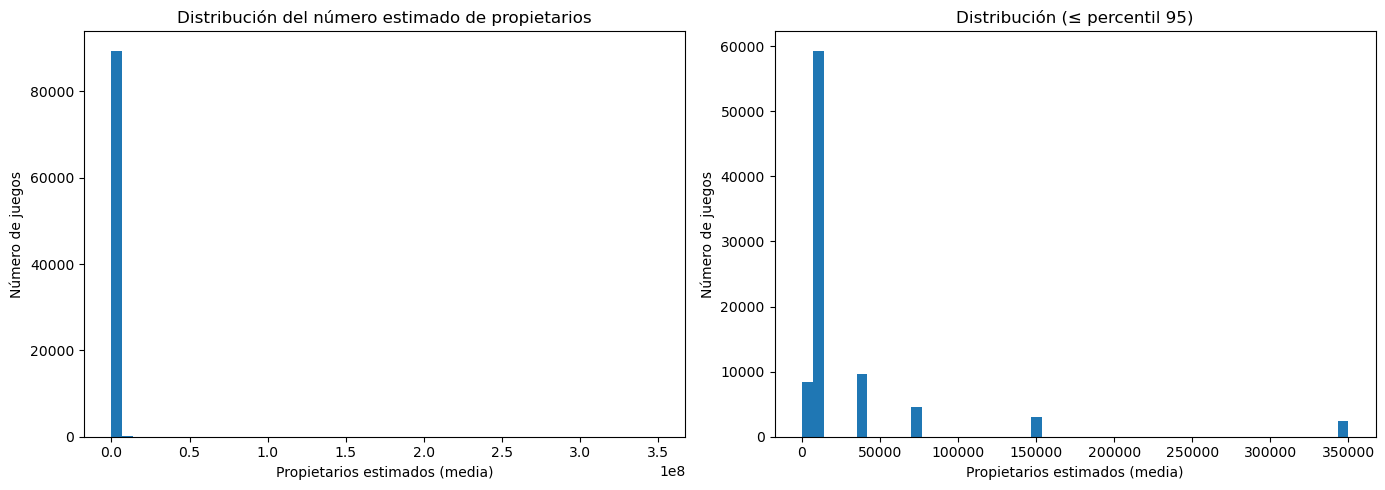

In [229]:
# Haremos dos gráficos, ya que lo más probable es que pase lo mismo que la variable anterior
fig, axes=plt.subplots(1, 2, figsize=(14, 5))

# Distribución completa
axes[0].hist(df["owners_mean"], bins=50)
axes[0].set_title("Distribución del número estimado de propietarios")
axes[0].set_xlabel("Propietarios estimados (media)")
axes[0].set_ylabel("Número de juegos")

# Distribución con zoom (percentil 95)
p95=df["owners_mean"].quantile(0.95)
df_owners_zoom=df[df["owners_mean"]<=p95]

axes[1].hist(df_owners_zoom["owners_mean"], bins=50)
axes[1].set_title("Distribución (≤ percentil 95)")
axes[1].set_xlabel("Propietarios estimados (media)")
axes[1].set_ylabel("Número de juegos")

plt.tight_layout()
plt.show()


La distribución del número estimado de propietarios muestra una fuerte asimetría, con la mayoría de los juegos concentrados en valores bajos y una minoría de títulos extremadamente populares. Incluso al limitar el análisis al percentil 95, se observa que la popularidad de los juegos sigue estando muy desigualmente repartida, lo que sugiere una elevada concentración del éxito en la plataforma.

#### Distribución del porcentaje de valoraciones positivas

In [230]:
# En la columna de pct_pos_total tendremos algunos valores de -1, lo que quiere decir que el juego no tuvo suficientes valoraciones. Los excluiremos
df_pct=df[df["pct_pos_total"]>=0]

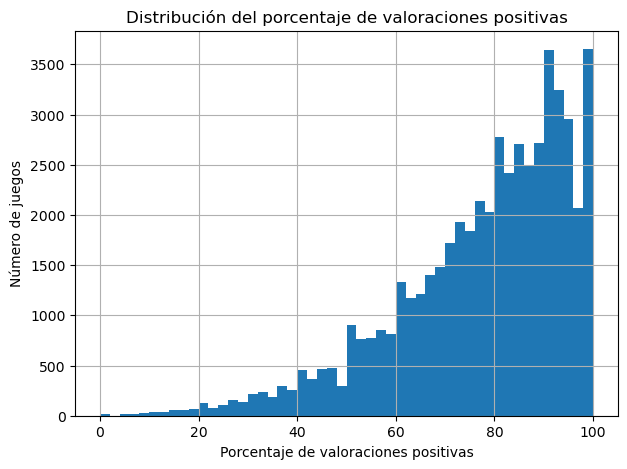

In [231]:
plt.figure(figsize=(7, 5))
df_pct["pct_pos_total"].hist(bins=50)
plt.title("Distribución del porcentaje de valoraciones positivas")
plt.xlabel("Porcentaje de valoraciones positivas")
plt.ylabel("Número de juegos")
plt.show()


La distribución del porcentaje de valoraciones positivas muestra una concentración en valores elevados, lo que indica que la mayoría de los juegos con suficientes reviews reciben una valoración generalmente favorable por parte de los usuarios.

#### Distribución del tiempo medio de juego

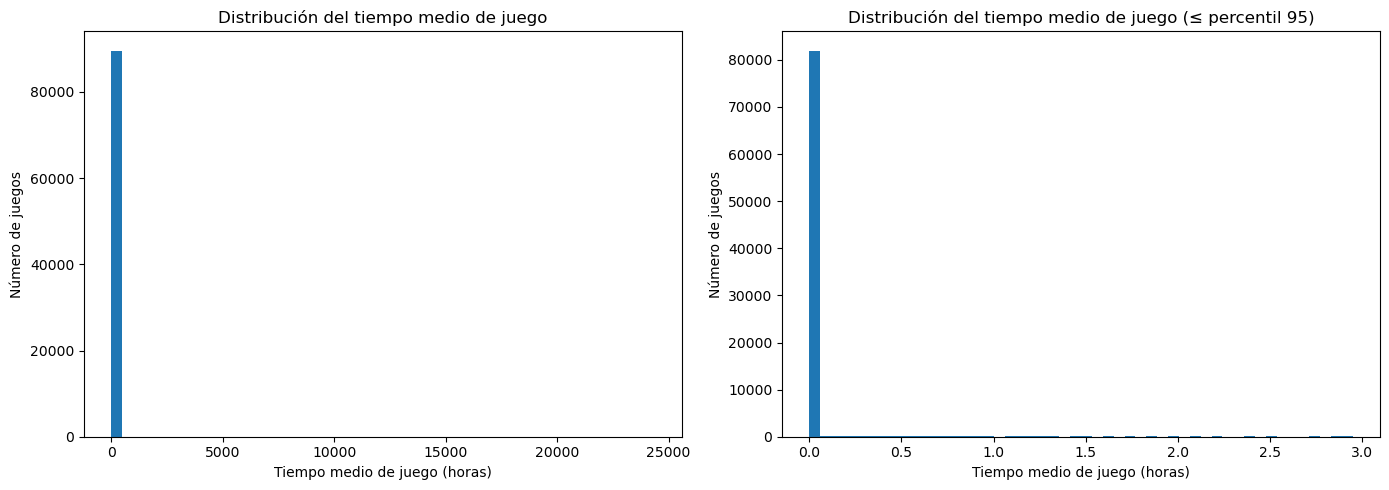

In [232]:
fig, axes=plt.subplots(1, 2, figsize=(14, 5))

# Conversión a horas
playtime_hours=df["average_playtime_forever"]/60

# Distribución completa
axes[0].hist(playtime_hours, bins=50)
axes[0].set_title("Distribución del tiempo medio de juego")
axes[0].set_xlabel("Tiempo medio de juego (horas)")
axes[0].set_ylabel("Número de juegos")

# Distribución con zoom (percentil 95)
p95_playtime=playtime_hours.quantile(0.95)
playtime_zoom=playtime_hours[playtime_hours<=p95_playtime]

axes[1].hist(playtime_zoom, bins=50)
axes[1].set_title("Distribución del tiempo medio de juego (≤ percentil 95)")
axes[1].set_xlabel("Tiempo medio de juego (horas)")
axes[1].set_ylabel("Número de juegos")

plt.tight_layout()
plt.show()



El tiempo medio de juego, expresado en horas, muestra una distribución claramente asimétrica. La mayoría de los juegos registran pocas horas de uso, mientras que una minoría concentra valores elevados.

### Comparaciones por género
#### Popularidad media por género

In [233]:
# Para las comparaciones por género no usaremos todos los géneros, solo los más populares, para evitar sobrecargar los gráficos
genre_popularity=(df[genre_cols].multiply(df["owners_mean"], axis=0).sum()/df[genre_cols].sum()).sort_values(ascending=False)

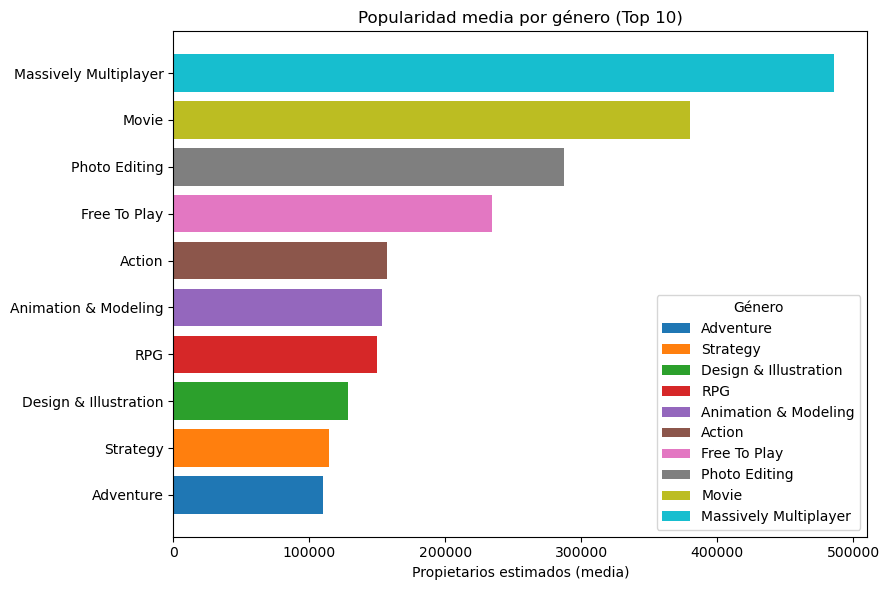

In [234]:
# Top 10 géneros ordenados
top_genres=genre_popularity.head(10).sort_values()

plt.figure(figsize=(9, 6))

# Generamos colores automáticos
colors=plt.cm.tab10(range(len(top_genres)))

# Hacemos un gráfico de barras horizontales
plt.barh(top_genres.index,top_genres.values,color=colors)

plt.xlabel("Propietarios estimados (media)")
plt.title("Popularidad media por género (Top 10)")

# Hacemos la leyenda. Se asocia un color con un género
legend_elements=[Patch(facecolor=colors[i], label=genre)for i, genre in enumerate(top_genres.index)]

plt.legend(handles=legend_elements,title="Género",loc="lower right")

plt.tight_layout()
plt.show()

De este gráfico obtenemos varias conclusiones importantes:
- Existen diferencias claras de popularidad entre géneros: La variación entre géneros es notable. Algunos géneros presentan, de media, un número de propietarios muy superior al resto, lo que indica que la popularidad no está uniformemente distribuida entre tipos de juegos.

- Los géneros con componente multijugador destacan claramente: El género Massively Multiplayer aparece como el más popular en términos medios. Esto sugiere que los juegos con un fuerte componente social o multijugador tienden a atraer a un mayor número de jugadores.

- Aparecen géneros no tradicionales entre los más populares: Géneros como Movie o Photo Editing aparecen entre los más populares, lo que indica que Steam no es exclusivamente una plataforma de videojuegos tradicionales, sino también de software interactivo con gran base de usuarios.

- Géneros clásicos no siempre lideran la popularidad media: Géneros como Adventure, Strategy o RPG, aunque muy frecuentes en el catálogo, presentan una popularidad media inferior a otros géneros, lo que sugiere que su éxito está más fragmentado entre muchos títulos.

#### Valoración media por género

In [235]:
# Filtramos juegos con valoración
df_pct=df[(df["pct_pos_total"].notna()) & (df["pct_pos_total"]>=0)]

# Cálculo de la valoración media por género
genre_rating=(df_pct[genre_cols].multiply(df_pct["pct_pos_total"], axis=0).sum()/df_pct[genre_cols].sum()).sort_values(ascending=False)

# Se realiza una limpieza de los valores con NaN (géneros que no tienen ninguna valoración)
genre_rating=genre_rating.dropna()

In [236]:
genre_rating

Accounting               93.000000
Design & Illustration    86.625000
Animation & Modeling     83.500000
Audio Production         81.750000
Casual                   78.191406
Video Production         78.000000
Indie                    77.721675
Adventure                77.185175
Free To Play             76.416086
Action                   76.274462
RPG                      75.753406
Racing                   75.745047
Sports                   74.800410
Strategy                 74.746496
Simulation               73.126563
Early Access             72.887823
Education                70.545455
Utilities                70.000000
Sexual Content           67.353846
Game Development         66.800000
Massively Multiplayer    64.665857
Nudity                   62.851351
Violent                  61.580392
Web Publishing           61.333333
Software Training        60.250000
Gore                     59.709091
Movie                    53.000000
dtype: float64

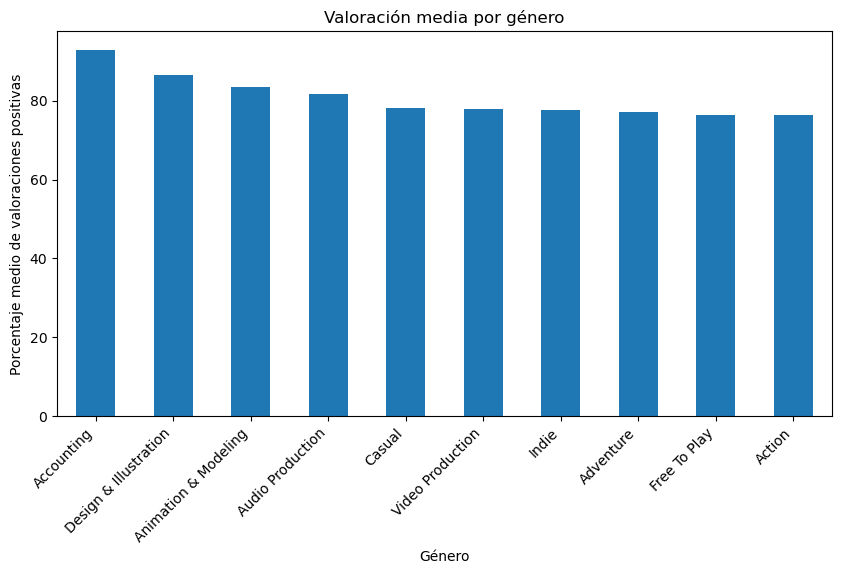

In [237]:
plt.figure(figsize=(10, 5))
genre_rating.head(10).plot(kind="bar")
plt.title("Valoración media por género")
plt.xlabel("Género")
plt.ylabel("Porcentaje medio de valoraciones positivas")
plt.xticks(rotation=45, ha="right")
plt.show()

La valoración media por género muestra niveles elevados en la mayoría de los casos, destacando especialmente géneros relacionados con software y herramientas creativas. Al comparar estos resultados con la popularidad media, se observa que los géneros más populares no son necesariamente los mejor valorados, lo que sugiere una mayor diferencia de opiniones de los usuarios en los géneros más masivos. Es decir, en los géneros más populares como Massively Multiplayer, Action o Free To Play, la diversidad de perfiles de usuarios y expectativas da lugar a opiniones más variadas, lo que se traduce en valoraciones medias más moderadas en comparación con géneros dirigidos a públicos más específicos.

#### Engagement por género

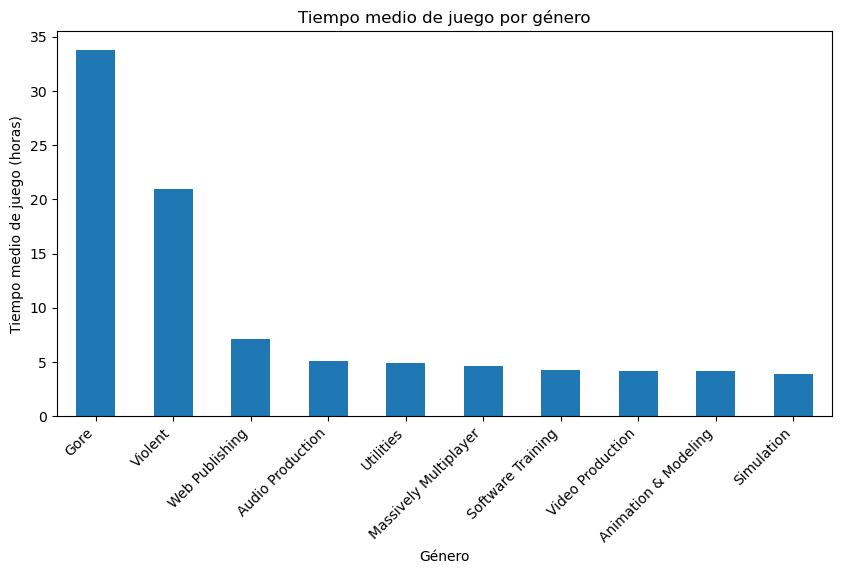

In [238]:
# Conversión a horas
playtime_hours=df["average_playtime_forever"]/60

# Cálculo del tiempo medio de juego por género
genre_playtime=(df[genre_cols].multiply(playtime_hours, axis=0).sum()/df[genre_cols].sum()).sort_values(ascending=False)

# Eliminamos posibles NaN
genre_playtime=genre_playtime.dropna()

# Gráfico
plt.figure(figsize=(10, 5))
genre_playtime.head(10).plot(kind="bar")
plt.title("Tiempo medio de juego por género")
plt.xlabel("Género")
plt.ylabel("Tiempo medio de juego (horas)")
plt.xticks(rotation=45, ha="right")
plt.show()


El análisis del tiempo medio de juego por género revela una fuerte heterogeneidad en el engagement, con unos pocos géneros que concentran valores especialmente elevados. Destacan, por un lado, etiquetas asociadas a contenido intenso (como Gore o Violent), lo que sugiere patrones de uso prolongados entre los usuarios que consumen ese tipo de experiencias. Por otro lado, la presencia de categorías vinculadas a software creativo (web publishing, producción de audio/vídeo, modelado o formación) refuerza el carácter híbrido de Steam como plataforma, donde el “playtime” puede reflejar tanto tiempo de juego como tiempo de uso de herramientas. En conjunto, los resultados confirman que popularidad, valoración y engagement capturan dimensiones distintas del comportamiento de los usuarios y deben interpretarse de forma complementaria. Como consideración metodológica, la interpretación de medias por género debe tener en cuenta el tamaño de muestra, ya que géneros con pocos títulos pueden presentar medias más sensibles a valores extremos.
#### Análisis comparativo por género: popularidad, valoración y engagement
La comparación conjunta de popularidad, valoración y tiempo medio de juego por género muestra que estas métricas no siguen un patrón único. Algunos géneros destacan por su elevada popularidad, mientras que otros, con un menor número de propietarios, presentan valoraciones medias más altas o un mayor tiempo de uso. Este resultado pone de manifiesto que el éxito de un género en Steam no puede evaluarse a partir de una única dimensión, sino que depende de una combinación de alcance, percepción de calidad y nivel de engagement por parte de los usuarios

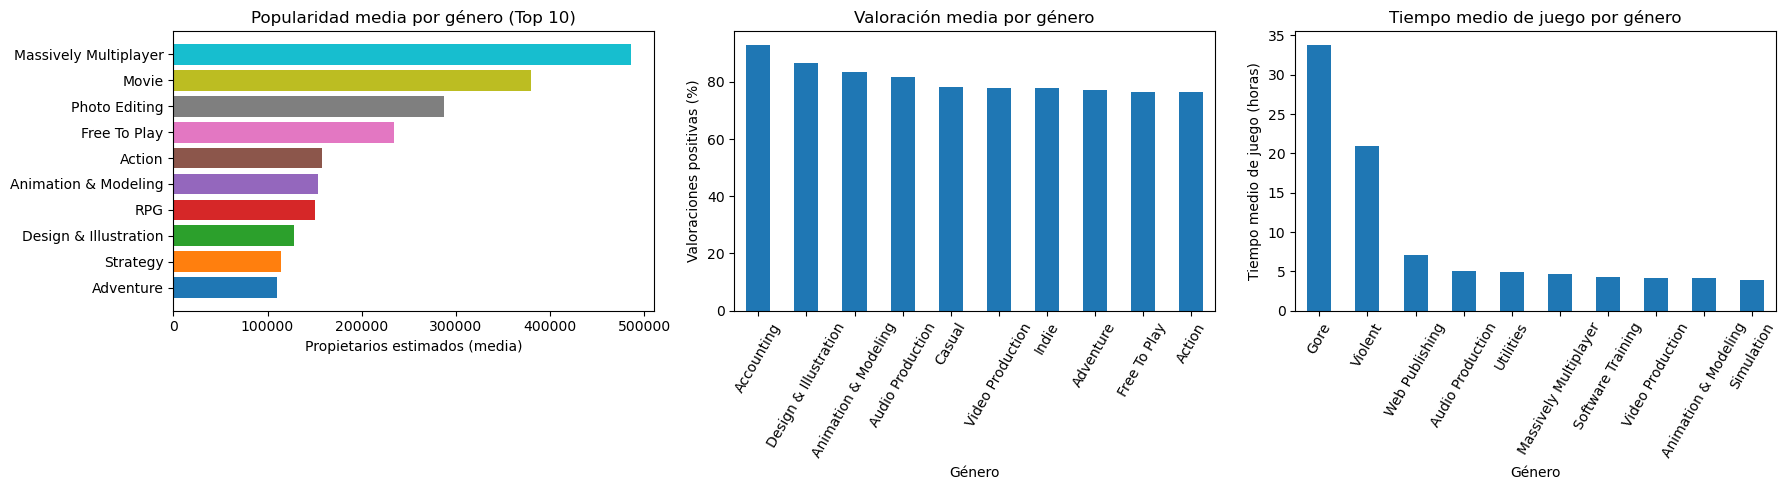

In [239]:
fig, axes=plt.subplots(1, 3, figsize=(18, 5))

# Popularidad media por género
axes[0].barh(top_genres.index,top_genres.values,color=colors)
axes[0].set_xlabel("Propietarios estimados (media)")
axes[0].set_title("Popularidad media por género (Top 10)")

# Valoración media por género
genre_rating.head(10).plot(kind="bar", ax=axes[1])
axes[1].set_title("Valoración media por género")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Valoraciones positivas (%)")
axes[1].tick_params(axis="x", rotation=60)

# Tiempo medio de juego por género
genre_playtime.head(10).plot(kind="bar", ax=axes[2] )
axes[2].set_title("Tiempo medio de juego por género")
axes[2].set_xlabel("Género")
axes[2].set_ylabel("Tiempo medio de juego (horas)")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

El análisis conjunto de popularidad, valoración y tiempo medio de juego por género pone de manifiesto que estas métricas reflejan dimensiones distintas del comportamiento de los usuarios en Steam. Mientras algunos géneros destacan por su alcance, otros sobresalen por la satisfacción de sus usuarios o por un uso más intensivo. Los resultados confirman que el éxito de un género no puede medirse mediante un único indicador, y que la interpretación conjunta de estas variables ofrece una visión más completa y matizada del ecosistema de la plataforma.

### Comparaciones por categoría
#### Análisis comparativo por categoría: popularidad, valoración y engagement

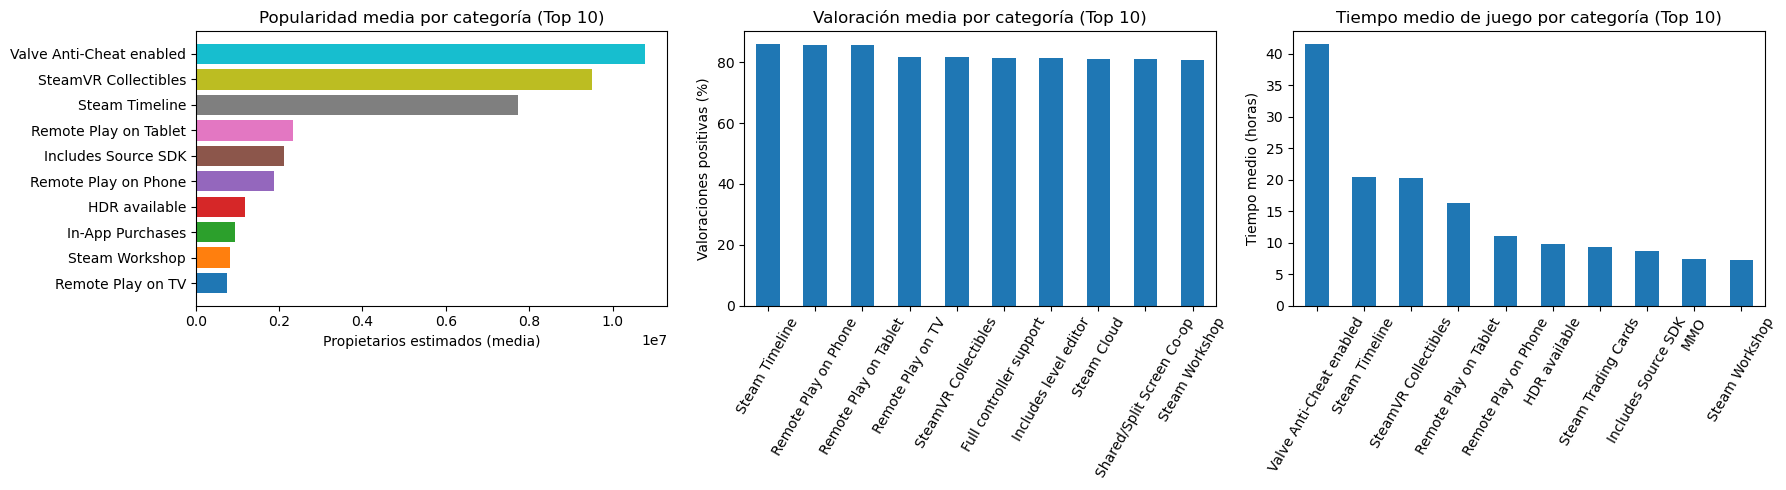

In [240]:
# Preparación de variables
playtime_hours=df["average_playtime_forever"]/60
df_pct=df[df["pct_pos_total"].notna() & (df["pct_pos_total"]>=0)]

# Popularidad media por categoría
cat_popularity=(df[cat_cols].multiply(df["owners_mean"], axis=0).sum()/df[cat_cols].sum()).sort_values(ascending=False).dropna()

# Valoración media por categoría
cat_rating=(df_pct[cat_cols].multiply(df_pct["pct_pos_total"], axis=0).sum()/df_pct[cat_cols].sum()).sort_values(ascending=False).dropna()

# Engagement medio por categoría
cat_playtime=(df[cat_cols].multiply(playtime_hours, axis=0).sum()/df[cat_cols].sum()).sort_values(ascending=False).dropna()

# Top 10
top_cat_pop=cat_popularity.head(10).sort_values()        # para barh
top_cat_rat=cat_rating.head(10)                          # bar vertical
top_cat_eng=cat_playtime.head(10)                        # bar vertical

# Colores para la primera gráfica (uno por categoría del top 10)
colors=plt.cm.tab10(range(len(top_cat_pop)))

# Gráficos
fig, axes=plt.subplots(1, 3, figsize=(18, 5))

# Popularidad: barras horizontales con colores
axes[0].barh(top_cat_pop.index, top_cat_pop.values, color=colors)
axes[0].set_title("Popularidad media por categoría (Top 10)")
axes[0].set_xlabel("Propietarios estimados (media)")

# Valoraciones
top_cat_rat.plot(kind="bar", ax=axes[1])
axes[1].set_title("Valoración media por categoría (Top 10)")
axes[1].set_ylabel("Valoraciones positivas (%)")
axes[1].tick_params(axis="x", rotation=60)

# Engagement
top_cat_eng.plot(kind="bar", ax=axes[2])
axes[2].set_title("Tiempo medio de juego por categoría (Top 10)")
axes[2].set_ylabel("Tiempo medio (horas)")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

El análisis conjunto de popularidad, valoración y tiempo medio de juego por categoría pone de manifiesto que estas variables reflejan principalmente características funcionales y estructurales de los juegos y de la propia plataforma Steam. Mientras la popularidad está dominada por categorías ampliamente integradas en títulos de gran alcance, la valoración media se mantiene elevada y homogénea, lo que sugiere que estas características no son determinantes en la percepción de calidad. Por su parte, el engagement se ve especialmente influido por categorías asociadas a experiencias competitivas y persistentes, reforzando la necesidad de analizar estas métricas de forma complementaria.
#### Análisis idiomas y número de propietarios

In [291]:
# Número de idiomas soportados por juego
df["num_languages"]=df[lang_cols].sum(axis=1)

# Agrupamos por número de idiomas y calculamos la popularidad media
popularity_by_langs=(df.groupby("num_languages")["owners_mean"].mean())

# Eliminamos valores extremos poco representativos (opcional pero recomendable)
popularity_by_langs=popularity_by_langs[popularity_by_langs.index<=20]


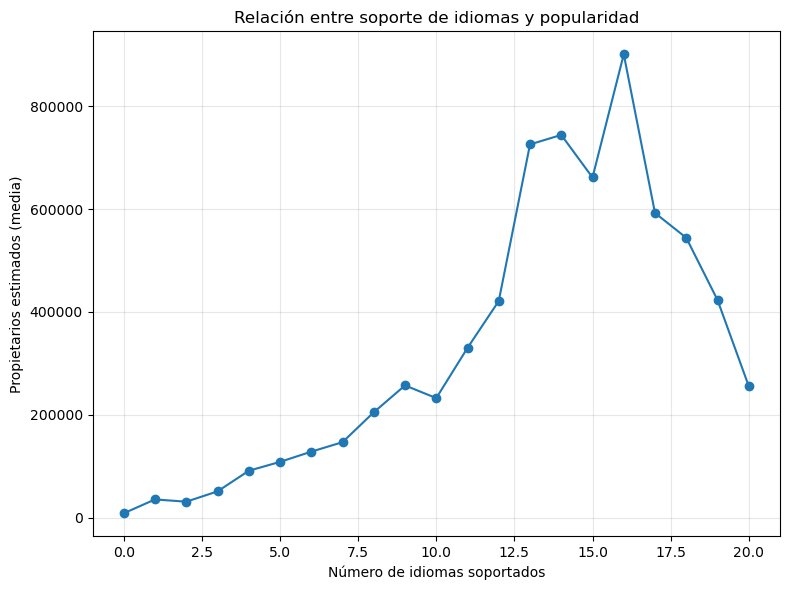

In [292]:
plt.figure(figsize=(8, 6))

plt.plot(popularity_by_langs.index,popularity_by_langs.values,marker="o")

plt.xlabel("Número de idiomas soportados")
plt.ylabel("Propietarios estimados (media)")
plt.title("Relación entre soporte de idiomas y popularidad")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico muestra una relación positiva entre el número de idiomas soportados y la popularidad media de los juegos. Los títulos con soporte multilingüe tienden a alcanzar una mayor base de usuarios, especialmente al pasar de pocos a varios idiomas, aunque a partir de cierto número de idiomas soportados (15-16) el efecto se atenúa.
#### Análisis agregado de developers y publishers
En este apartado se analiza el rendimiento agregado de desarrolladores y editores en la plataforma Steam. El objetivo es identificar patrones generales en términos de popularidad, valoración y engagement, a partir de la agregación de métricas a nivel de entidad.

In [241]:
# Explode
df_dev=df.explode("developers_list")

# Limpiamos valores vacíos
df_dev=df_dev[df_dev["developers_list"].notna() & (df_dev["developers_list"]!="")]

df_pub=df.explode("publishers_list")
df_pub=df_pub[df_pub["publishers_list"].notna() & (df_pub["publishers_list"]!="")]

In [242]:
dev_popularity = (df_dev.groupby("developers_list")["owners_mean"].mean().sort_values(ascending=False))

dev_popularity.head(20)


developers_list
PUBG Corporation                   7.500000e+07
Amazon Games                       7.500000e+07
Smartly Dressed Games              7.500000e+07
Smilegate RPG                      7.500000e+07
Valve                              4.061000e+07
Respawn                            3.787500e+07
Blue Mammoth Games                 3.500000e+07
Wallpaper Engine Team              3.500000e+07
Iron Gate AB                       3.500000e+07
Re-Logic                           3.500000e+07
ConcernedApe                       3.500000e+07
24 Entertainment                   3.500000e+07
Gaijin Entertainment               3.500000e+07
OVERKILL - a Starbreeze Studio.    3.500000e+07
Eleventh Hour Games                3.500000e+07
Rockstar North                     2.750333e+07
Game Science                       2.550000e+07
Endnight Games Ltd                 2.500000e+07
Grinding Gear Games                2.125000e+07
Arrowhead Game Studios             2.087500e+07
Name: owners_mean, dtype

In [243]:
pub_popularity=(df_pub.groupby("publishers_list")["owners_mean"].mean().sort_values(ascending=False))

pub_popularity.head(20)

publishers_list
Smartly Dressed Games                    7.500000e+07
Amazon Games                             5.000000e+07
Valve                                    4.245667e+07
Eleventh Hour Games                      3.500000e+07
NetEase Games Global                     3.500000e+07
Endnight Games Ltd                       3.500000e+07
Bungie                                   3.500000e+07
Wallpaper Engine Team                    3.500000e+07
ConcernedApe                             3.500000e+07
Game Science                             2.550000e+07
Grinding Gear Games                      2.125000e+07
Pocketpair                               1.923125e+07
Innersloth                               1.757500e+07
Re-Logic                                 1.757500e+07
Activision (Excluding Japan and Asia)    1.500000e+07
VRChat Inc.                              1.500000e+07
Newnight                                 1.500000e+07
鬼谷工作室                                    1.500000e+07
方块游戏 (Asia) 

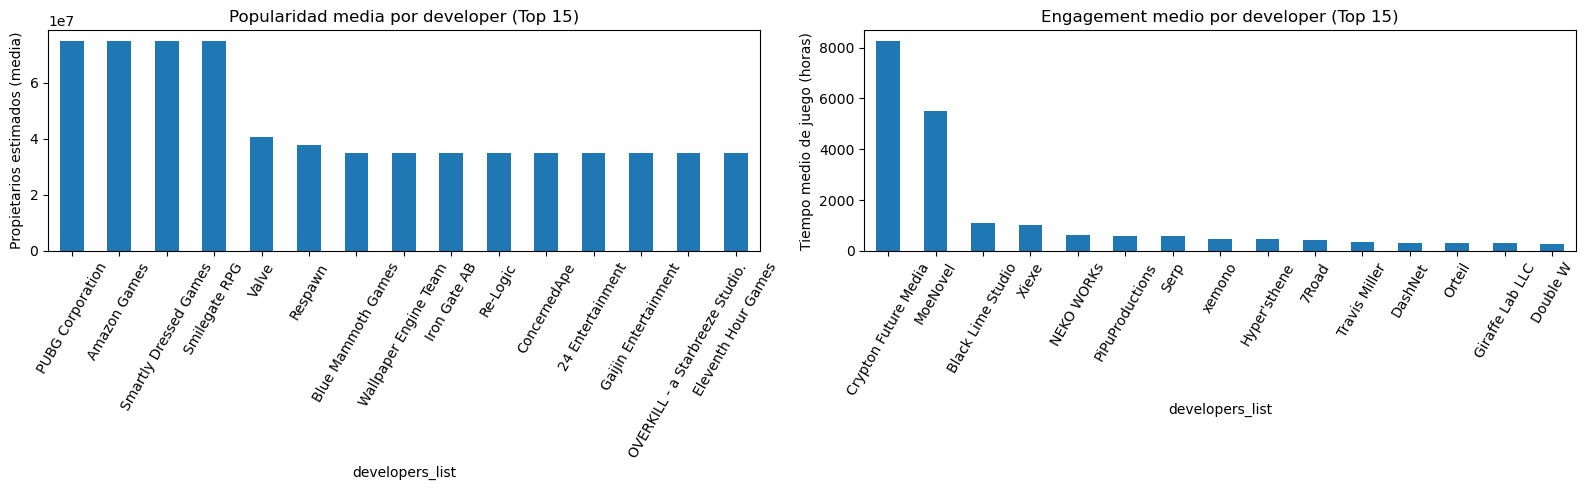

In [244]:
# Filtramos valoraciones válidas, las de mayor a 0 y las que no son NaN
df_dev_rating=df_dev[df_dev["pct_pos_total"].notna() & (df_dev["pct_pos_total"] >= 0)]

# Popularidad media por developer
dev_popularity=(df_dev.groupby("developers_list")["owners_mean"].mean().sort_values(ascending=False))

# Engagement medio por developer
dev_engagement=(df_dev.groupby("developers_list")["average_playtime_forever"].mean().sort_values(ascending=False))/60 

# Gráficos
fig, axes=plt.subplots(1, 2, figsize=(16, 5))

dev_popularity.head(15).plot(kind="bar", ax=axes[0])
axes[0].set_title("Popularidad media por developer (Top 15)")
axes[0].set_ylabel("Propietarios estimados (media)")
axes[0].tick_params(axis="x", rotation=60)

dev_engagement.head(15).plot(kind="bar", ax=axes[1])
axes[1].set_title("Engagement medio por developer (Top 15)")
axes[1].set_ylabel("Tiempo medio de juego (horas)")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

C:\Users\Acer Predator\AppData\Local\Temp\ipykernel_17860\94179177.py:23: UserWarning: Glyph 40509 (\N{CJK UNIFIED IDEOGRAPH-9E3D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Acer Predator\AppData\Local\Temp\ipykernel_17860\94179177.py:23: UserWarning: Glyph 23627 (\N{CJK UNIFIED IDEOGRAPH-5C4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Acer Predator\AppData\Local\Temp\ipykernel_17860\94179177.py:23: UserWarning: Glyph 35895 (\N{CJK UNIFIED IDEOGRAPH-8C37}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 40509 (\N{CJK UNIFIED IDEOGRAPH-9E3D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23627 (\N{CJK UNIFIED IDEOGRAPH-5C4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\anaconda3\Lib\site-packages\IPython\core\p

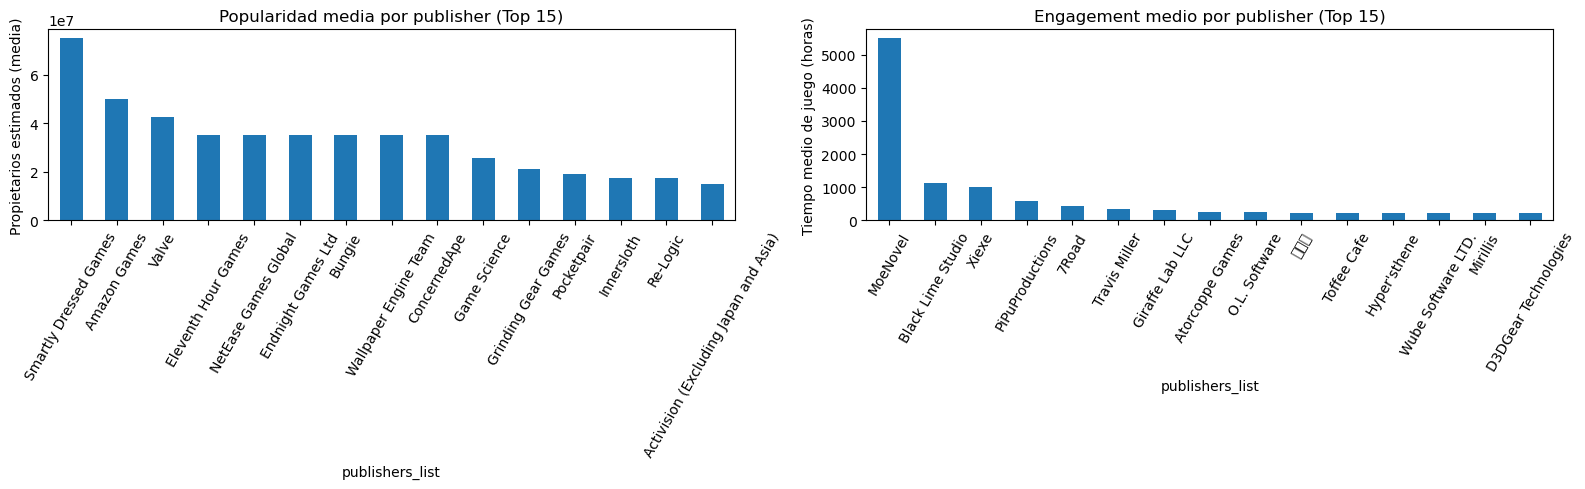

In [245]:
# Tiempo de juego en horas
df_pub["playtime_hours"]=df_pub["average_playtime_forever"]/60

# Popularidad media por publisher
pub_popularity=(df_pub.groupby("publishers_list")["owners_mean"].mean().sort_values(ascending=False))

# Engagement medio por publisher
pub_engagement=(df_pub.groupby("publishers_list")["playtime_hours"].mean().sort_values(ascending=False))

# Gráficos
fig, axes=plt.subplots(1, 2, figsize=(16, 5))

pub_popularity.head(15).plot(kind="bar", ax=axes[0])
axes[0].set_title("Popularidad media por publisher (Top 15)")
axes[0].set_ylabel("Propietarios estimados (media)")
axes[0].tick_params(axis="x", rotation=60)

pub_engagement.head(15).plot(kind="bar", ax=axes[1])
axes[1].set_title("Engagement medio por publisher (Top 15)")
axes[1].set_ylabel("Tiempo medio de juego (horas)")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()


Algunos nombres de desarrolladores y editores contienen caracteres no latinos, lo que puede provocar advertencias de renderizado en las visualizaciones sin afectar al análisis.

El análisis conjunto de popularidad y engagement por desarrolladores y editores muestra que el alcance de una entidad en Steam no garantiza un mayor nivel de uso por parte de los jugadores. Mientras algunas entidades concentran grandes bases de usuarios, otras destacan por generar experiencias con un mayor tiempo medio de juego. Estos resultados refuerzan la idea de que el éxito en la plataforma debe evaluarse desde una perspectiva multidimensional.
#### Matriz de correlaciones
Calcularemos la matriz de correlaciones entre las variables numéricas no binarizadas del dataset con el objetivo de identificar relaciones lineales relevantes.

In [246]:
# Seleccionamos solo columnas numéricas, ya que tenemos muchas columnas de listas, strings o tuplas
df_numeric=df.select_dtypes(include=["int64", "float64"])

# Eliminamos columnas binarias (0/1), ya que muchas de nuestras columnas son binarizaciones de otras
df_numeric=df_numeric.loc[:, df_numeric.nunique()>2]

corr_matrix=df_numeric.corr()
corr_matrix
df_numeric.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'achievements', 'recommendations', 'positive', 'negative',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent',
       'num_reviews_recent', 'owners_mean'],
      dtype='object')

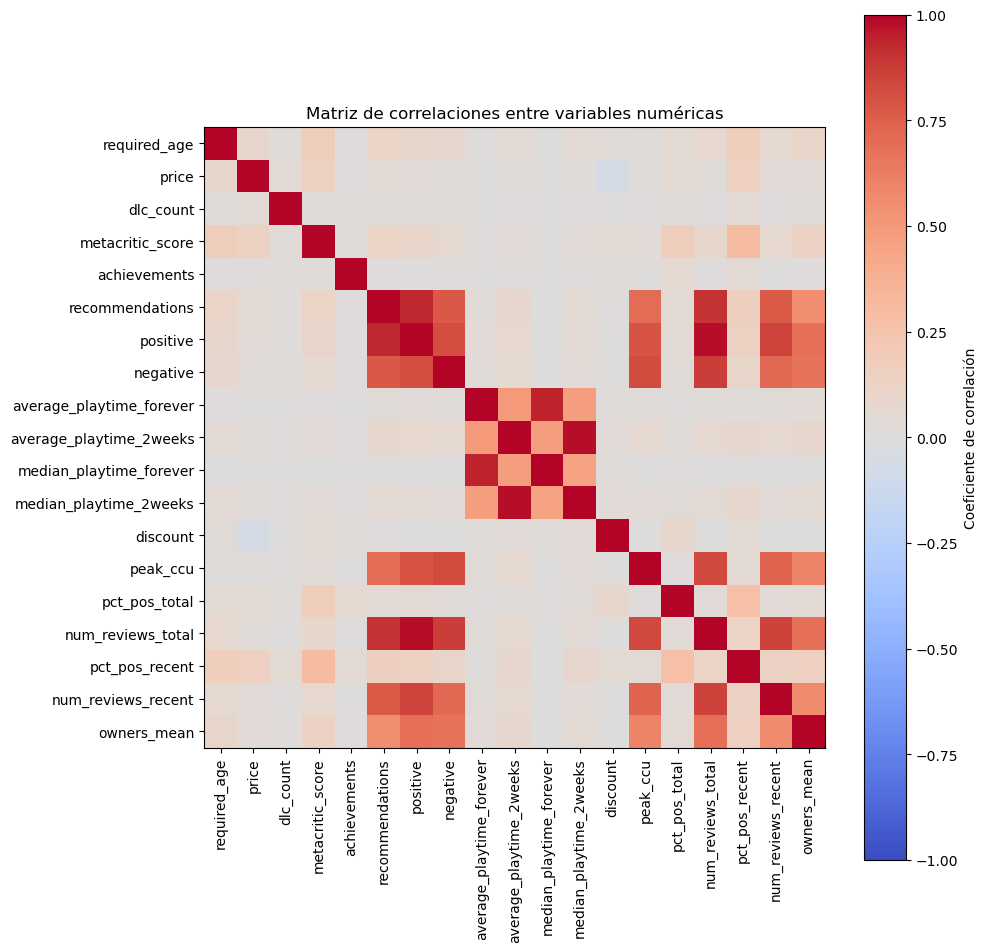

In [247]:
# Creamos la matriz de correlaciones
corr_matrix=df_numeric.corr()
plt.figure(figsize=(10, 10))
plt.imshow(corr_matrix,cmap="coolwarm",vmin=-1,vmax=1)
plt.colorbar(label="Coeficiente de correlación")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Matriz de correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()


Los resultados muestran correlaciones elevadas entre variables relacionadas con la actividad de los usuarios, como número de reseñas, valoraciones positivas y tiempo de juego, mientras que otras variables como el precio o la edad requerida presentan una relación débil con la mayoría de métricas. Este análisis refuerza la necesidad de interpretar los indicadores de forma conjunta y no aislada.
#### Evolución temporal de géneros

In [299]:
# Número de juegos por año y género
genre_year = df.groupby("release_year")[genre_cols].sum()

# En porcentaje
genre_year_pct=genre_year.div(genre_year.sum(axis=1), axis=0)*100

# El top 5 géneros
top_genres = genre_year.sum().sort_values(ascending=False).head(5).index
genre_year_pct_top = genre_year_pct[top_genres]


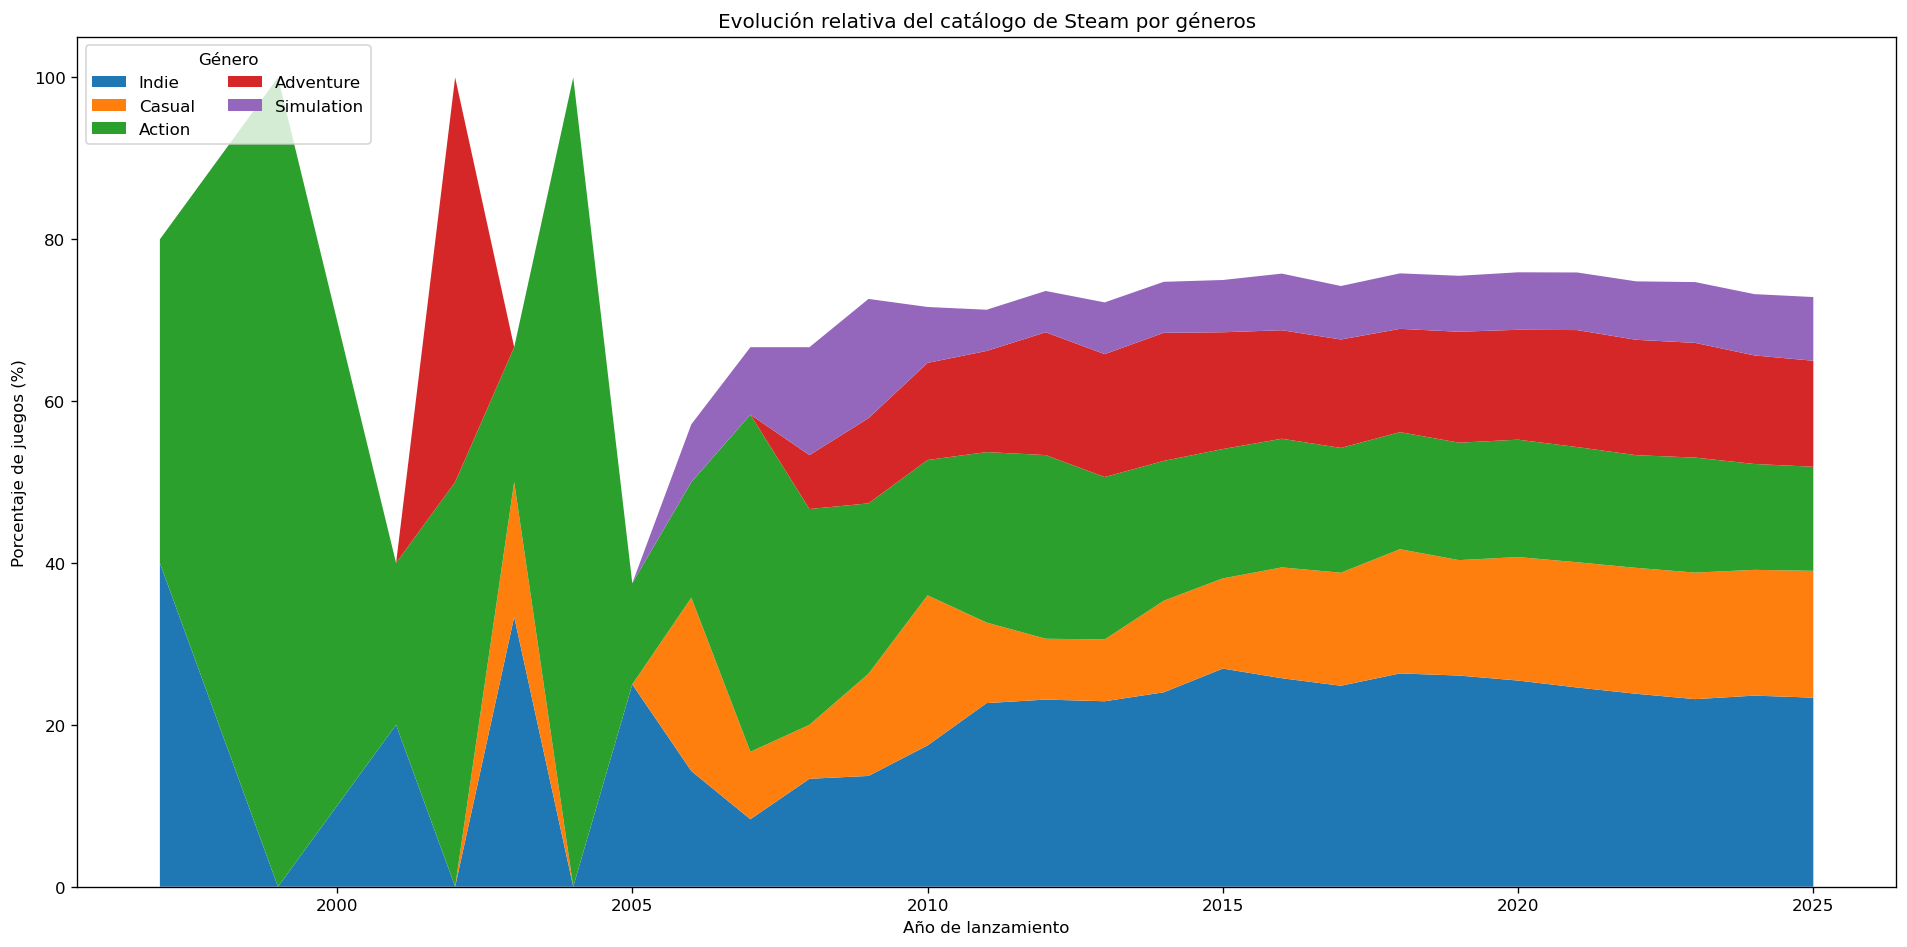

In [301]:
plt.figure(figsize=(16, 8), dpi=120)

plt.stackplot(genre_year_pct_top.index,genre_year_pct_top.T.values, labels=genre_year_pct_top.columns)

plt.title("Evolución relativa del catálogo de Steam por géneros")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Porcentaje de juegos (%)")

plt.legend(title="Género", loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


En los primeros años del catálogo se observan fuertes oscilaciones en las proporciones debido al reducido número de lanzamientos anuales. A medida que el volumen de juegos aumenta, las distribuciones se estabilizan y permiten identificar tendencias estructurales más representativas.
#### Distribución de juegos por sistema operativo

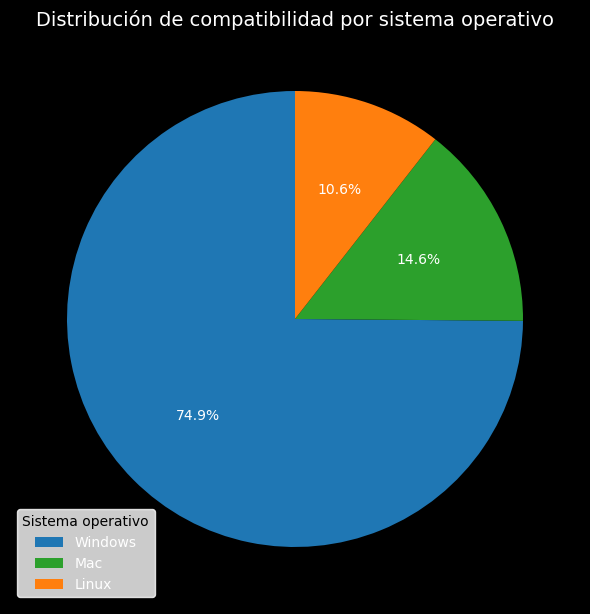

In [302]:
# Hacemos un diccionario relacionando el sistema operativo con el número de juegos que lo soportan
os_counts={"Windows": df["windows"].sum(), "Mac": df["mac"].sum(), "Linux": df["linux"].sum()}

labels=list(os_counts.keys())
values=list(os_counts.values())

# Colores bien contrastados para fondo negro
colors=["#1f77b4", "#2ca02c", "#ff7f0e"]

# Figura sobre fondo negro
fig, ax=plt.subplots(figsize=(6, 7), facecolor="black")
ax.set_facecolor("black")

# Gráfica pastel
wedges, texts, autotexts=ax.pie(values,colors=colors,autopct="%1.1f%%",startangle=90,textprops={"color": "white"})

# Título
ax.set_title("Distribución de compatibilidad por sistema operativo",color="white",fontsize=14)

# Leyenda
ax.legend(wedges,labels,title="Sistema operativo",loc="lower left",facecolor="white",edgecolor="white",labelcolor="white")

plt.tight_layout()
plt.show()

El gráfico de pastel muestra la distribución global de la compatibilidad por sistema operativo en el catálogo de Steam. Se observa un claro predominio de juegos compatibles con Windows, mientras que Mac y Linux presentan una presencia significativamente menor.
#### Representación temporal de la valoración media del top 5 géneros

In [251]:
# Año de lanzamiento
df["release_year"]=df["release_date"].dt.year

# Escogeremos el top 5 géneros más jugados históricamente
# Engagement en horas
playtime_hours=df["average_playtime_forever"]/60

# Cálculo del engagement medio por género
genre_playtime=(df[genre_cols].multiply(playtime_hours, axis=0).sum()/df[genre_cols].sum())

# Top 5 géneros más jugados históricamente
top_5_genres=genre_playtime.sort_values(ascending=False).head(5).index.tolist()

In [252]:
genre_year_rating={}

# Cálculo de la serie temporal de cada género
for genre in selected_genres:
    genre_year_rating[genre]=(df_line[df_line[genre]==1].groupby("release_year")["pct_pos_total"].mean())

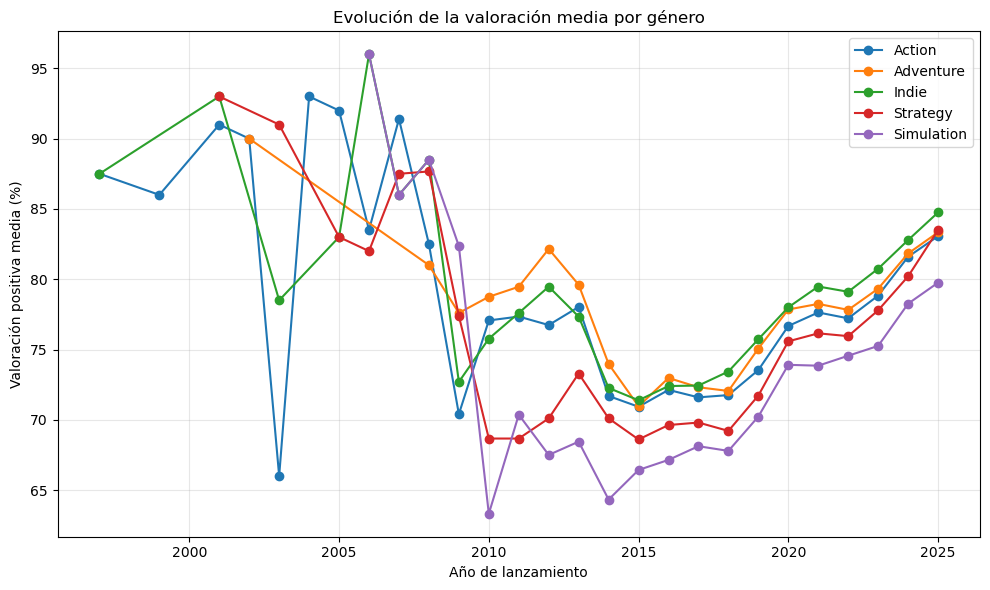

In [253]:
plt.figure(figsize=(10, 6))

# 5 líneas
for genre, series in genre_year_rating.items():
    plt.plot(series.index, series.values, marker="o", label=genre)

plt.xlabel("Año de lanzamiento")
plt.ylabel("Valoración positiva media (%)")
plt.title("Evolución de la valoración media por género")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


El gráfico muestra una caída generalizada de la valoración media por género en torno a 2008–2012, seguida de una recuperación progresiva y una estabilización en los años recientes. Aunque existen diferencias entre géneros, las valoraciones tienden a converger, lo que sugiere una mayor homogeneidad en la calidad percibida de los juegos del catálogo de Steam.
#### Palabras más comunes en las reviews
Se realiza un análisis exploratorio del texto disponible en la columna reviews mediante un proceso básico de limpieza, eliminación de ruido y stopwords, y conteo de frecuencias. Las visualizaciones permiten identificar los términos más recurrentes presentes en las reseñas textuales asociadas a los juegos del catálogo.

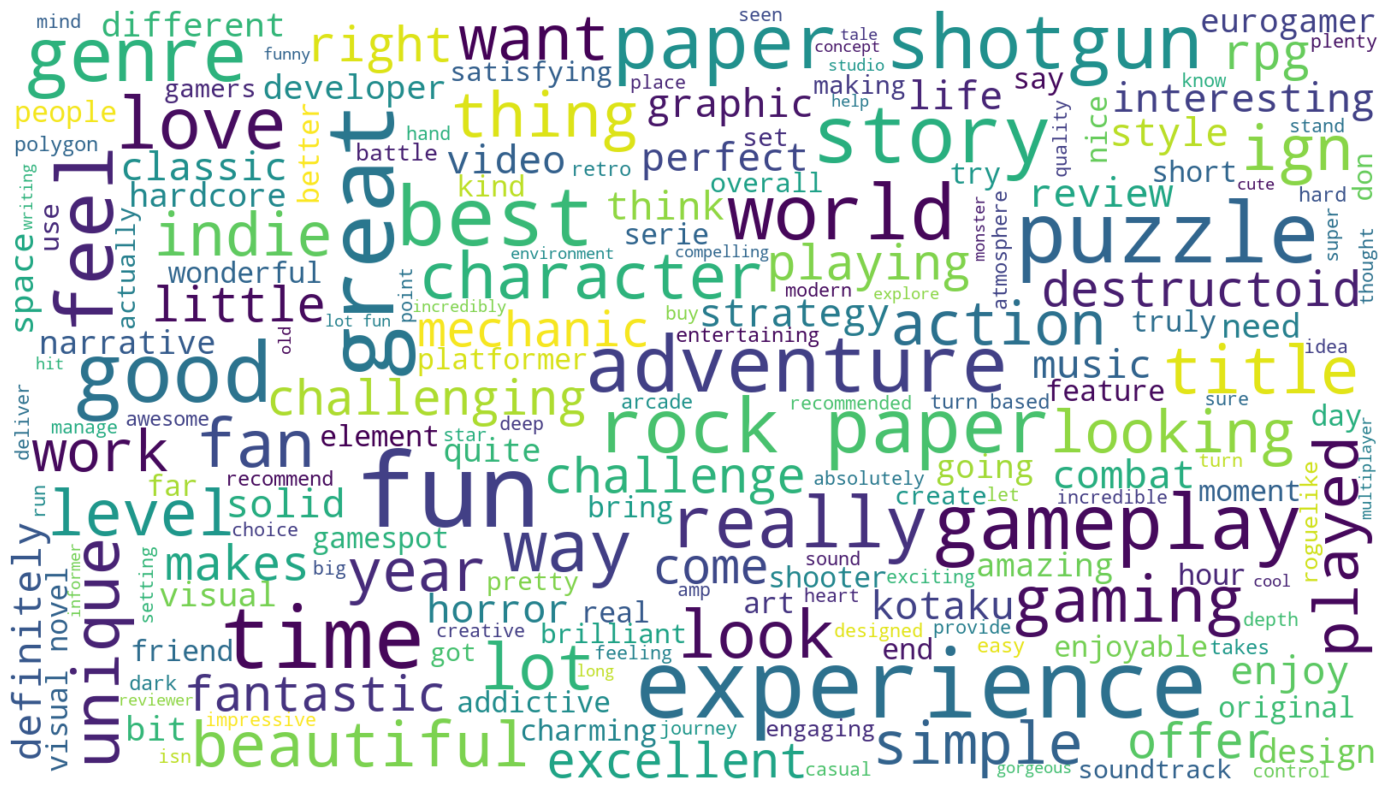

In [288]:
# Unimos todo el texto limpio
all_text=" ".join(reviews_clean)

wordcloud=WordCloud(width=1600,height=900,max_font_size=120,background_color="white", colormap="viridis").generate(all_text)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

Podemos ver visualmente las palabras más repetidas en las reviews: fun, like, great, experience.

# 6. Conclusión
En este trabajo se ha realizado un análisis exploratorio exhaustivo del catálogo de juegos de Steam a partir de un dataset de gran tamaño y alta heterogeneidad. Tras una fase inicial de limpieza y preparación de los datos, hemos construido un dataset final coherente que ha permitido abordar el análisis cuantitativo y descriptivo.

El análisis exploratorio ha puesto de manifiesto la fuerte asimetría existente en variables clave como el precio, el número de propietarios o el tiempo de juego, evidenciando la presencia de pocos juegos extremadamente populares frente a una mayoría de juegos con impacto limitado. Asimismo, se ha observado que la popularidad, la valoración de los usuarios y el engagement no siempre evolucionan de forma paralela, lo que sugiere que el éxito comercial no garantiza necesariamente una mejor percepción por parte de los jugadores.

El estudio comparativo por géneros y categorías ha permitido identificar patrones diferenciados de comportamiento. Algunos géneros destacan por su alta popularidad, otros por una valoración media elevada y otros por un mayor tiempo de juego, reflejando distintos tipos de experiencias y perfiles de usuario. Además, el análisis temporal ha revelado una evolución clara del catálogo de Steam, con un crecimiento acelerado del número de lanzamientos y una posterior estabilización de la calidad percibida por los usuarios en los años más recientes.

El análisis agregado de desarrolladores y editores ha mostrado una elevada concentración del mercado, donde un número reducido de actores acumula gran parte de la popularidad y el engagement, mientras que una larga cola de estudios independientes presenta resultados más modestos pero, en muchos casos, valoraciones positivas consistentes.

Finalmente, la inclusión de un análisis textual exploratorio de las reseñas ha aportado una dimensión cualitativa al estudio, permitiendo identificar los términos más recurrentes en las reviews y reforzando las conclusiones obtenidas a partir de las variables numéricas.

# 7. Bibliografía
Kaggle. Steam Games Dataset. https://www.kaggle.com/datasets/artermiloff/steam-games-dataset

    Fuente del conjunto de datos analizado en este trabajo.

Chatgpt - Prompt: "¿Como se quitan carácteres como BBCode de una lista?"

          Respuesta: "Para quitar caracteres BBCode (por ejemplo [b], [/b], [i], etc.) de una lista de strings, la forma correcta y general es usar expresiones regulares y aplicarlas elemento a elemento. Te lo explico de forma clara, con opción simple y opción general. 
          Opción recomendada (general y correcta): usando re.sub
            import re
            limpieza = [re.sub(r"\[\/?\w+\]", "", l).strip() for s in lista_sucia]"
            
Matplotlib Development Team. Matplotlib documentation. https://matplotlib.org/stable/

    Utilizada para la generación de histogramas, gráficos de barras, líneas, dispersión y visualizaciones personalizadas.

Python Software Foundation. ast — Abstract Syntax Trees. https://docs.python.org/3/library/ast.html

    Referencia para el uso de ast.literal_eval en la conversión segura de strings a estructuras de datos nativas.

Pandas Cheatsheet. https://www.datacamp.com/cheat-sheet/pandas-cheat-sheet-for-data-science-in-python

Numpy Cheatsheet. https://www.datacamp.com/cheat-sheet/numpy-cheat-sheet-data-analysis-in-python

Matplotlib Cheatsheet. https://www.datacamp.com/cheat-sheet/matplotlib-cheat-sheet-plotting-in-python

Seaborn Cheatsheet. https://www.datacamp.com/cheat-sheet/python-seaborn-cheat-sheet

Apuntes propios y de la asignatura